# Advanced Block Mode Tutorial: Lorenz-Driven Green Machine

This notebook is the larger-system example in the Block mode tutorial sequence.

The MZI lattice tutorial introduced S-parameters, vector fitting, state-space filters, and the basic directed Block mode run. The 16-QAM tutorial introduced multimode signals and more involved plotting. Here we use those ideas to build a Lorenz-driven Green Machine reservoir.

In this notebook we:

1. Generate a compact Lorenz drive signal.
2. Use that signal to drive a Mach-Zehnder style phase encoder.
3. Fan the encoded optical signal into delayed taps.
4. Feed those taps into a measured Green Machine S-parameter block.
5. Run Block mode and inspect the time-domain outputs.

## What this example adds

Block mode still passes full time blocks between components. For optical signals the amplitude array has shape:

```text
(T, L, M)
```

where `T` is time, `L` is wavelength, and `M` is mode.

This tutorial focuses on things the earlier tutorials only touched lightly:

- custom source and modulator components,
- an external measured S-parameter data file,
- a larger directed netlist with fanout and delay taps,
- many top-level output ports from one reservoir block.

To keep runtime reasonable, this example uses one optical mode and a downsampled Lorenz signal.

In [24]:
from functools import lru_cache
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from commpy.filters import rrcosfilter
from scipy.integrate import solve_ivp
from scipy.signal import upfirdn

from simphony.circuit.circuit import Circuit
from simphony.component.component import BlockModeComponent
from simphony.component.port import Port
from simphony.libraries.siepic import waveguide, y_branch
from simphony.signal.block_mode import BlockModeOpticalSignal
from simphony.simulation.block_mode import BlockModeSimulation, BlockModeSimulationParameters
from simphony.utils import resample


## 1. Create the Lorenz drive waveforms

The Lorenz system gives us a rich, non-periodic signal without needing an external dataset. We generate it on a fine grid for the attractor plot, then downsample it before sending it through the photonic circuit.

That split is intentional: the figure can look smooth while the Block mode simulation stays small.

The final drive is converted into two complementary phase waveforms. One drives the upper MZI arm and the other drives the lower arm, creating a time-varying optical encoder before the Green Machine reservoir.

In [25]:
SIGMA, RHO, BETA = 10.0, 28.0, 8 / 3
NUM_LORENZ_STEPS = 300
LORENZ_DT = 0.05
DIAGRAM_UPSAMPLE = 10
SAMPLES_PER_SYMBOL = 32
RRC_ROLLOFF = 0.35
RRC_SPAN = 8
MODULATION_DEPTH = np.pi / 4


def lorenz(_, xyz):
    x, y, z = xyz
    return [
        SIGMA * (y - x),
        x * (RHO - z) - y,
        x * y - BETA * z,
    ]


def minmax(u):
    u = np.asarray(u)
    return (u - u.min()) / (u.max() - u.min() + 1e-12)


def rrc_shape(symbols, taps, samples_per_symbol):
    shaped = upfirdn(
        taps.astype(np.float32),
        np.asarray(symbols, dtype=np.float32),
        up=samples_per_symbol,
    )
    group_delay = (len(taps) - 1) // 2
    shaped = shaped[group_delay : group_delay + len(symbols) * samples_per_symbol]
    return jnp.asarray(shaped, dtype=jnp.float32)


stop_time = LORENZ_DT * (NUM_LORENZ_STEPS - 1)
fine_dt = LORENZ_DT / DIAGRAM_UPSAMPLE
t_lorenz_fine = np.arange(0.0, stop_time + 1e-12, fine_dt)

solution = solve_ivp(
    lorenz,
    (0.0, stop_time),
    (0.0, 1.0, 1.05),
    method='RK45',
    max_step=fine_dt,
    t_eval=t_lorenz_fine,
)

x_lorenz_fine, y_lorenz_fine, z_lorenz_fine = solution.y

x_lorenz = x_lorenz_fine[::DIAGRAM_UPSAMPLE]
y_lorenz = y_lorenz_fine[::DIAGRAM_UPSAMPLE]
z_lorenz = z_lorenz_fine[::DIAGRAM_UPSAMPLE]

combined_drive = minmax(x_lorenz) + minmax(y_lorenz)
combined_drive = 2 * minmax(combined_drive) - 1

_, rrc_taps = rrcosfilter(
    RRC_SPAN * SAMPLES_PER_SYMBOL + 1,
    RRC_ROLLOFF,
    1.0,
    SAMPLES_PER_SYMBOL,
)

phase_1_symbols = np.pi / 2 + MODULATION_DEPTH * combined_drive / 2
phase_2_symbols = -np.pi / 2 - MODULATION_DEPTH * combined_drive / 2
phase_wave1 = rrc_shape(phase_1_symbols, rrc_taps, SAMPLES_PER_SYMBOL)
phase_wave2 = rrc_shape(phase_2_symbols, rrc_taps, SAMPLES_PER_SYMBOL)

print(f'Lorenz diagram samples: {x_lorenz_fine.shape[0]}')
print(f'Lorenz symbols passed to Block mode: {x_lorenz.shape[0]}')
print(f'Block mode time samples: {phase_wave1.shape[0]}')

Lorenz diagram samples: 2991
Lorenz symbols passed to Block mode: 300
Block mode time samples: 9600


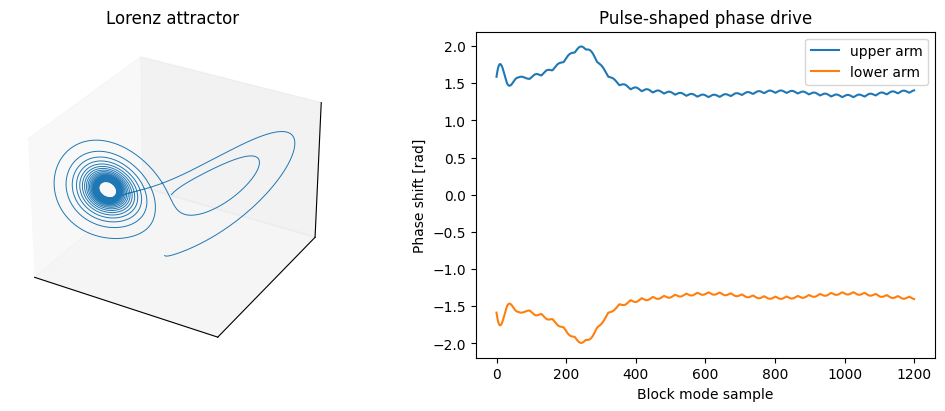

In [26]:
fig = plt.figure(figsize=(10, 4), constrained_layout=True)

ax0 = fig.add_subplot(1, 2, 1, projection='3d')
ax0.plot(x_lorenz_fine, y_lorenz_fine, z_lorenz_fine, linewidth=0.7)
ax0.set_title('Lorenz attractor')
ax0.set_xticks([])
ax0.set_yticks([])
ax0.set_zticks([])

ax1 = fig.add_subplot(1, 2, 2)
ax1.plot(np.asarray(phase_wave1[:1200]), label='upper arm')
ax1.plot(np.asarray(phase_wave2[:1200]), label='lower arm')
ax1.set_title('Pulse-shaped phase drive')
ax1.set_xlabel('Block mode sample')
ax1.set_ylabel('Phase shift [rad]')
ax1.legend()
plt.show()


## 2. Define the custom Block mode components

This circuit uses two small custom components:

- `MultiWavelengthCWLaser` creates a constant optical field on each carrier wavelength.
- `TimeVaryingPhaseModulator` applies `exp(1j * phase[t])` to an incoming optical signal.

A custom Block mode component needs:

1. `ports`: class-level `Port` objects with names, types, and directionality.
2. `__init__(simulation_parameters, **settings)`: per-instance setup from the settings dictionary.
3. `block_mode_response(input_signals, simulation_parameters)`: full-block input to full-block output.

For optical components, return `BlockModeOpticalSignal` objects. Their amplitude arrays should usually keep the `(T, L, M)` shape unless the component intentionally changes wavelength or mode content.

In [27]:
class MultiWavelengthCWLaser(BlockModeComponent):
    ports = [Port(name='o0', type='optical', directionality='output')]

    def __init__(self, simulation_parameters, *, wavelengths, mode_idx=0):
        self.wavelengths = jnp.atleast_1d(jnp.asarray(wavelengths, dtype=jnp.float32))
        self.mode_idx = int(mode_idx)

    def block_mode_response(self, inputs, simulation_parameters):
        num_time_steps = simulation_parameters.num_time_steps
        num_wavelengths = self.wavelengths.shape[0]
        num_modes = len(simulation_parameters.mode_identifiers)

        amplitude = jnp.zeros(
            (num_time_steps, num_wavelengths, num_modes),
            dtype=jnp.complex64,
        )
        amplitude = amplitude.at[:, :, self.mode_idx].set(1.0 + 0.0j)

        return {'o0': BlockModeOpticalSignal(amplitude=amplitude, wavelength=self.wavelengths)}


class TimeVaryingPhaseModulator(BlockModeComponent):
    ports = [
        Port(name='o0', type='optical', directionality='input'),
        Port(name='o1', type='optical', directionality='output'),
    ]

    def __init__(self, simulation_parameters, *, phase=0.0):
        self.phase = jnp.asarray(phase, dtype=jnp.float32)

    def block_mode_response(self, input_signals, simulation_parameters):
        optical_in = input_signals['o0']

        if self.phase.ndim == 0:
            phase = jnp.full((simulation_parameters.num_time_steps,), self.phase)
        else:
            if self.phase.shape[0] != simulation_parameters.num_time_steps:
                raise ValueError('The phase drive length must match num_time_steps.')
            phase = self.phase

        coeff = jnp.exp(1j * phase)[:, None, None]
        return {
            'o1': BlockModeOpticalSignal(
                amplitude=optical_in.amplitude * coeff,
                wavelength=optical_in.wavelength,
            )
        }

## 3. Wrap the Green Machine S-parameter data

The Green Machine is loaded as a measured S-parameter dictionary. The `.npz` file stores wavelength samples plus arrays named by port pair. The helper below converts those arrays into the SAX dictionary form:

```python
{('out_port', 'in_port'): s_parameter_values}
```

Unit convention: this SAX-style model receives `wl` in microns during fitting, while Block mode simulation wavelengths are stored in meters. That is why the loaded wavelength grid remains around `1.5` to `1.6`, while the simulation parameters later use values like `1.55e-6`.

In [28]:
GREEN_MACHINE_FILE = Path('lumerical_bestfit_sdict_back.npz')


@lru_cache(maxsize=1)
def load_green_machine_sdict(filename=str(GREEN_MACHINE_FILE)):
    filename = Path(filename)
    if not filename.exists():
        raise FileNotFoundError(
            f'Missing {filename}. Put the Green Machine S-parameter file next to this notebook.'
        )

    data = np.load(filename)
    stored_wavelengths_um = data['wavelengths']
    sdict = {}

    for key in data.files:
        if key == 'wavelengths':
            continue
        _, to_port, from_port = key.split('_', 2)
        sdict[(to_port, from_port)] = np.squeeze(data[key])

    return stored_wavelengths_um, sdict


def green_machine(wl=1.55):
    stored_wavelengths_um, stored_sparams = load_green_machine_sdict()
    requested_wavelengths_um = jnp.asarray(wl).reshape(-1)
    return resample(requested_wavelengths_um, stored_wavelengths_um, stored_sparams)


## 4. Build the circuit netlist

The netlist has the usual three dictionaries: `instances`, `connections`, and `ports`.

For Block mode, write each connection as directed signal flow:

```python
'upstream_instance,upstream_port': 'downstream_instance,downstream_port'
```

If `port_directionality` is not specified for an S-parameter component, Simphony can infer it from this ordering: left-hand ports are outputs, right-hand-only ports are inputs, and unconnected S-parameter ports default to outputs.

The layout is:

- a reference laser feeds `green_machine,in0`,
- a signal laser feeds a Lorenz-driven MZI encoder,
- a fanout tree splits the encoded signal,
- delay ladders create seven delayed taps,
- the taps feed `green_machine,in1` through `green_machine,in7`,
- all eight Green Machine outputs are exposed as top-level ports.

In [29]:
def make_lorenz_green_machine_netlist():
    instances = {
        'signal_laser': 'laser',
        'reference_laser': 'laser',
        'mzi_splitter': 'y_branch',
        'mzi_upper_wg': 'waveguide',
        'mzi_lower_wg': 'waveguide',
        'mzi_upper_mod': 'phase_modulator',
        'mzi_lower_mod': 'phase_modulator',
        'mzi_combiner': 'y_branch',
        'reference_delay': 'waveguide',
        **{f'fanout_{name}': 'y_branch' for name in 'abcdefg'},
        **{f'tap_delay_{idx}': 'waveguide' for idx in range(1, 8)},
        'green_machine': 'green_machine',
    }

    connections = {
        # Reference path.
        'reference_laser,o0': 'reference_delay,o0',
        'reference_delay,o1': 'green_machine,in0',

        # Lorenz-driven MZI encoder.
        'signal_laser,o0': 'mzi_splitter,port_1',
        'mzi_splitter,port_2': 'mzi_upper_wg,o0',
        'mzi_splitter,port_3': 'mzi_lower_wg,o0',
        'mzi_upper_wg,o1': 'mzi_upper_mod,o0',
        'mzi_lower_wg,o1': 'mzi_lower_mod,o0',
        'mzi_upper_mod,o1': 'mzi_combiner,port_2',
        'mzi_lower_mod,o1': 'mzi_combiner,port_3',

        # Binary fanout tree.
        'mzi_combiner,port_1': 'fanout_a,port_1',
        'fanout_a,port_2': 'fanout_b,port_1',
        'fanout_a,port_3': 'fanout_c,port_1',
        'fanout_b,port_2': 'fanout_d,port_1',
        'fanout_b,port_3': 'fanout_e,port_1',
        'fanout_c,port_2': 'fanout_f,port_1',
        'fanout_c,port_3': 'fanout_g,port_1',

        # Seven tap starts. Extra delay sections are added in the loop below.
        'fanout_d,port_2': 'tap_delay_1,o0',
        'tap_delay_1,o1': 'green_machine,in1',
        'fanout_d,port_3': 'tap_delay_2,o0',
        'fanout_e,port_2': 'tap_delay_3,o0',
        'fanout_e,port_3': 'tap_delay_4,o0',
        'fanout_f,port_2': 'tap_delay_5,o0',
        'fanout_f,port_3': 'tap_delay_6,o0',
        'fanout_g,port_2': 'tap_delay_7,o0',
    }

    netlist = {
        'instances': instances,
        'connections': connections,
        'ports': {f'out{i}': f'green_machine,out{i}' for i in range(8)},
    }

    # Tap i gets i total delay sections before entering green_machine,in{i}.
    for tap_idx in range(2, 8):
        previous_port = f'tap_delay_{tap_idx},o1'
        for delay_idx in range(tap_idx - 1):
            delay_name = f'extra_delay_{tap_idx}_{delay_idx}'
            netlist['instances'][delay_name] = 'waveguide'
            netlist['connections'][previous_port] = f'{delay_name},o0'
            previous_port = f'{delay_name},o1'
        netlist['connections'][previous_port] = f'green_machine,in{tap_idx}'

    return netlist


models = {
    'laser': MultiWavelengthCWLaser,
    'phase_modulator': TimeVaryingPhaseModulator,
    'waveguide': waveguide,
    'y_branch': y_branch,
    'green_machine': green_machine,
}

netlist = make_lorenz_green_machine_netlist()
circuit = Circuit(netlist=netlist, models=models)

print(f'Circuit instances: {len(netlist["instances"])}')
print(f'Circuit connections: {len(netlist["connections"])}')
print('Top-level ports:', sorted(netlist['ports']))

Circuit instances: 45
Circuit connections: 51


## 5. Configure component settings

The settings dictionary supplies per-instance constructor arguments.

Custom Block mode components read their settings directly. For example, the lasers receive `wavelengths`, and the phase modulators receive their phase waveforms.

SAX/S-parameter components need Block mode metadata too:

- `sax_settings`: kwargs passed into the SAX model.
- `port_directionality`: explicit input/output roles for the directed graph.
- `vector_fitting_parameters`: controls for converting wavelength-domain S-parameters into time-domain filters.

Caveat from the earlier tutorials: if an S-parameter setting includes `port_directionality` or `vector_fitting_parameters`, include `sax_settings` as well. Use `sax_settings: {}` when the SAX model has no kwargs.

In [30]:
WAVELENGTHS_M = jnp.array([1.53e-6, 1.54e-6, 1.55e-6, 1.56e-6, 1.57e-6], dtype=jnp.float32)
SIMULATION_DT = 1e-14
NUM_TIME_STEPS = int(phase_wave1.shape[0])

SHORT_WG_LENGTH = 10
BASE_DELAY_LENGTH = 100
TAP_DELAY_LENGTH = 366

vector_fitting_parameters = {
    'model_order': 24,
    'min_model_order': 2,
    'max_model_order': 24,
    'num_frequency_samples': 400,
    'center_wavelength': 1.55e-6,
    'spectral_range': (1.5e-6, 1.6e-6),
}

splitter_directionality = {'port_1': 'input', 'port_2': 'output', 'port_3': 'output'}
combiner_directionality = {'port_1': 'output', 'port_2': 'input', 'port_3': 'input'}
waveguide_directionality = {'o0': 'input', 'o1': 'output'}


def waveguide_settings(length):
    return {
        'sax_settings': {'length': length},
        'port_directionality': waveguide_directionality,
        'vector_fitting_parameters': vector_fitting_parameters.copy(),
    }


settings = {
    'signal_laser': {'wavelengths': WAVELENGTHS_M},
    'reference_laser': {'wavelengths': WAVELENGTHS_M},
    'mzi_upper_mod': {'phase': phase_wave1},
    'mzi_lower_mod': {'phase': phase_wave2},
    'mzi_splitter': {'sax_settings': {}, 'port_directionality': splitter_directionality},
    'mzi_combiner': {'sax_settings': {}, 'port_directionality': combiner_directionality},
    'green_machine': {
        'sax_settings': {},
        'port_directionality': {
            **{f'in{i}': 'input' for i in range(8)},
            **{f'out{i}': 'output' for i in range(8)},
        },
        'vector_fitting_parameters': vector_fitting_parameters.copy(),
    },
}

for name in [f'fanout_{letter}' for letter in 'abcdefg']:
    settings[name] = {'sax_settings': {}, 'port_directionality': splitter_directionality}

for name in ['mzi_upper_wg', 'mzi_lower_wg']:
    settings[name] = waveguide_settings(SHORT_WG_LENGTH)

for name in ['reference_delay', *[f'tap_delay_{idx}' for idx in range(1, 8)]]:
    settings[name] = waveguide_settings(BASE_DELAY_LENGTH)

for instance_name in netlist['instances']:
    if instance_name.startswith('extra_delay_'):
        settings[instance_name] = waveguide_settings(TAP_DELAY_LENGTH)

print(f'Settings entries: {len(settings)}')

## 6. Run the Block mode simulation

`BlockModeSimulationParameters` define the shared time grid and optical channels. The source wavelengths, phase waveforms, and fitted S-parameter filters must agree with these global parameters.

This notebook uses one mode, `TE`, because multimode behavior was covered in the 16-QAM tutorial. The Green Machine example is mainly about composing a larger directed circuit around a measured S-parameter block.

In [31]:
simulation_parameters = BlockModeSimulationParameters(
    optical_baseband_wavelengths=WAVELENGTHS_M,
    dt=SIMULATION_DT,
    num_time_steps=NUM_TIME_STEPS,
    mode_identifiers=['TE'],
)

simulation = BlockModeSimulation(
    circuit,
    settings=settings,
    simulation_parameters=simulation_parameters,
)

result = simulation.run()

print('Top-level output ports:', sorted(result.output_signals))
for port_name, signal in sorted(result.output_signals.items()):
    print(f'{port_name}: amplitude shape = {signal.amplitude.shape}')


Top-level output ports: ['out0', 'out1', 'out2', 'out3', 'out4', 'out5', 'out6', 'out7']
out0: amplitude shape = (9600, 5, 1)
out1: amplitude shape = (9600, 5, 1)
out2: amplitude shape = (9600, 5, 1)
out3: amplitude shape = (9600, 5, 1)
out4: amplitude shape = (9600, 5, 1)
out5: amplitude shape = (9600, 5, 1)
out6: amplitude shape = (9600, 5, 1)
out7: amplitude shape = (9600, 5, 1)


## 7. Inspect the output signals

Each top-level Green Machine port returns a `BlockModeOpticalSignal`. To inspect one trace, select:

```python
amplitude[:, wavelength_index, mode_index]
```

The plot below shows optical power for one output and one carrier wavelength.

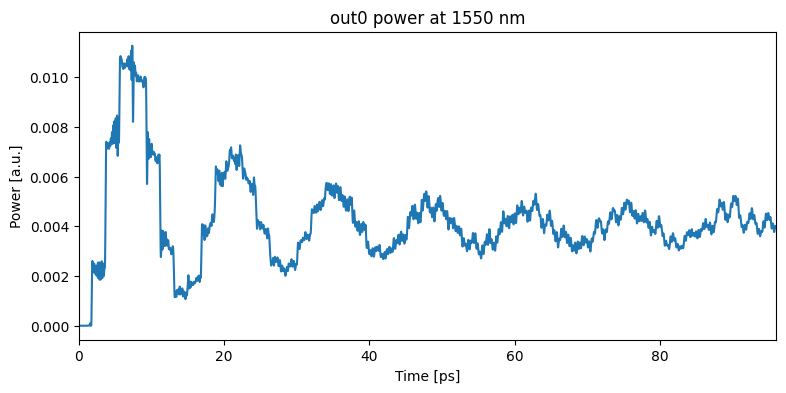

In [32]:
output_port = 'out0'
wavelength_index = 2
mode_index = 0

output_signal = result.output_signals[output_port]
field = output_signal.amplitude[:, wavelength_index, mode_index]
power = np.asarray(jnp.abs(field) ** 2)

time_ps = np.arange(power.shape[0]) * SIMULATION_DT * 1e12

plt.figure(figsize=(9, 4))
plt.plot(time_ps, power)
plt.title(f'{output_port} power at {float(WAVELENGTHS_M[wavelength_index]) * 1e9:.0f} nm')
plt.xlabel('Time [ps]')
plt.ylabel('Power [a.u.]')
plt.margins(x=0)
plt.show()


## Recap

This example keeps the same Block mode workflow as the earlier tutorials, but applies it to a larger reservoir-style circuit:

1. Generate the Lorenz drive.
2. Define the small custom source and phase-modulator components.
3. Load measured Green Machine S-parameters as a SAX-style model.
4. Build a directed netlist with fanout and delay taps.
5. Provide `sax_settings`, directionality, and vector-fitting settings for S-parameter components.
6. Run `BlockModeSimulation` and read full-block outputs from `result.output_signals`.

The key difference from the starter examples is scale: the simulator still runs each component once on a full block, but the directed graph now contains many delayed paths feeding one measured multiport component.